# Risk of losing privacy with rare categories

When dealing with data with rare categories, there is a risk of disclosing more information than intended about small groups.


## Demonstration of the problem

Suppose the following happens:

In [1]:
from sklearn.datasets import make_classification
from synthpop.utils import str_dtype
import pandas as pd
X, y = make_classification(
        random_state=42,
        n_samples=100,
        n_classes=10,
        n_informative=11,
    )
# By "accident", the floatingpoint numbers are cast to strings
X = X[:,0:1].astype(str_dtype)
X

array([['1.3705361439967134'],
       ['-0.1115088271429437'],
       ['1.0587285298838789'],
       ['1.0706105599791862'],
       ['-1.1617838439123638'],
       ['-0.7557915001583629'],
       ['1.0294574815983573'],
       ['1.2769653860881878'],
       ['0.3207857259326839'],
       ['-0.695694877197064'],
       ['0.13106518621584873'],
       ['0.22526411724754952'],
       ['0.7760279138434754'],
       ['-1.9670697035871523'],
       ['1.063940987560856'],
       ['0.007178466907941942'],
       ['-1.5678594253654559'],
       ['0.3123782104665717'],
       ['-1.5350402475323597'],
       ['1.0417246640588513'],
       ['0.4968735905075971'],
       ['1.1373145423647293'],
       ['0.6928557558178116'],
       ['-0.7146806769904318'],
       ['0.47004418736820214'],
       ['0.2927154821418534'],
       ['1.0819848092499422'],
       ['0.5320061988219431'],
       ['-0.81240234893742'],
       ['1.3764964500195378'],
       ['-0.15024298879825998'],
       ['1.3995946451457935

Note that the column is categorical. Every value is unique.
Now we want to synthesise the target:

In [2]:
from synthpop.methods.cart_synth import TreeClassifierMethod
method = TreeClassifierMethod()

X = {i: X[:, i] for i in range(X.shape[1])}
y = y.astype(str_dtype)
synth_data = method.fit_transform(X,y)
y

array(['4', '0', '5', '1', '0', '1', '7', '6', '4', '4', '8', '0', '3',
       '0', '0', '6', '3', '7', '3', '0', '8', '6', '5', '9', '2', '0',
       '5', '6', '3', '3', '7', '7', '6', '6', '9', '2', '6', '8', '9',
       '7', '3', '9', '8', '1', '2', '5', '3', '9', '4', '2', '3', '5',
       '4', '9', '0', '7', '3', '0', '1', '4', '5', '2', '8', '6', '1',
       '3', '7', '8', '8', '7', '8', '9', '4', '9', '9', '4', '1', '7',
       '2', '4', '7', '0', '1', '1', '9', '6', '5', '5', '2', '2', '6',
       '8', '5', '1', '5', '2', '0', '8', '2', '4'],
      dtype=StringDType(na_object=nan))

Then we see the problem, **the target column is copied completly**:

In [3]:
(synth_data == y).all()

np.True_

## Why does this happen?

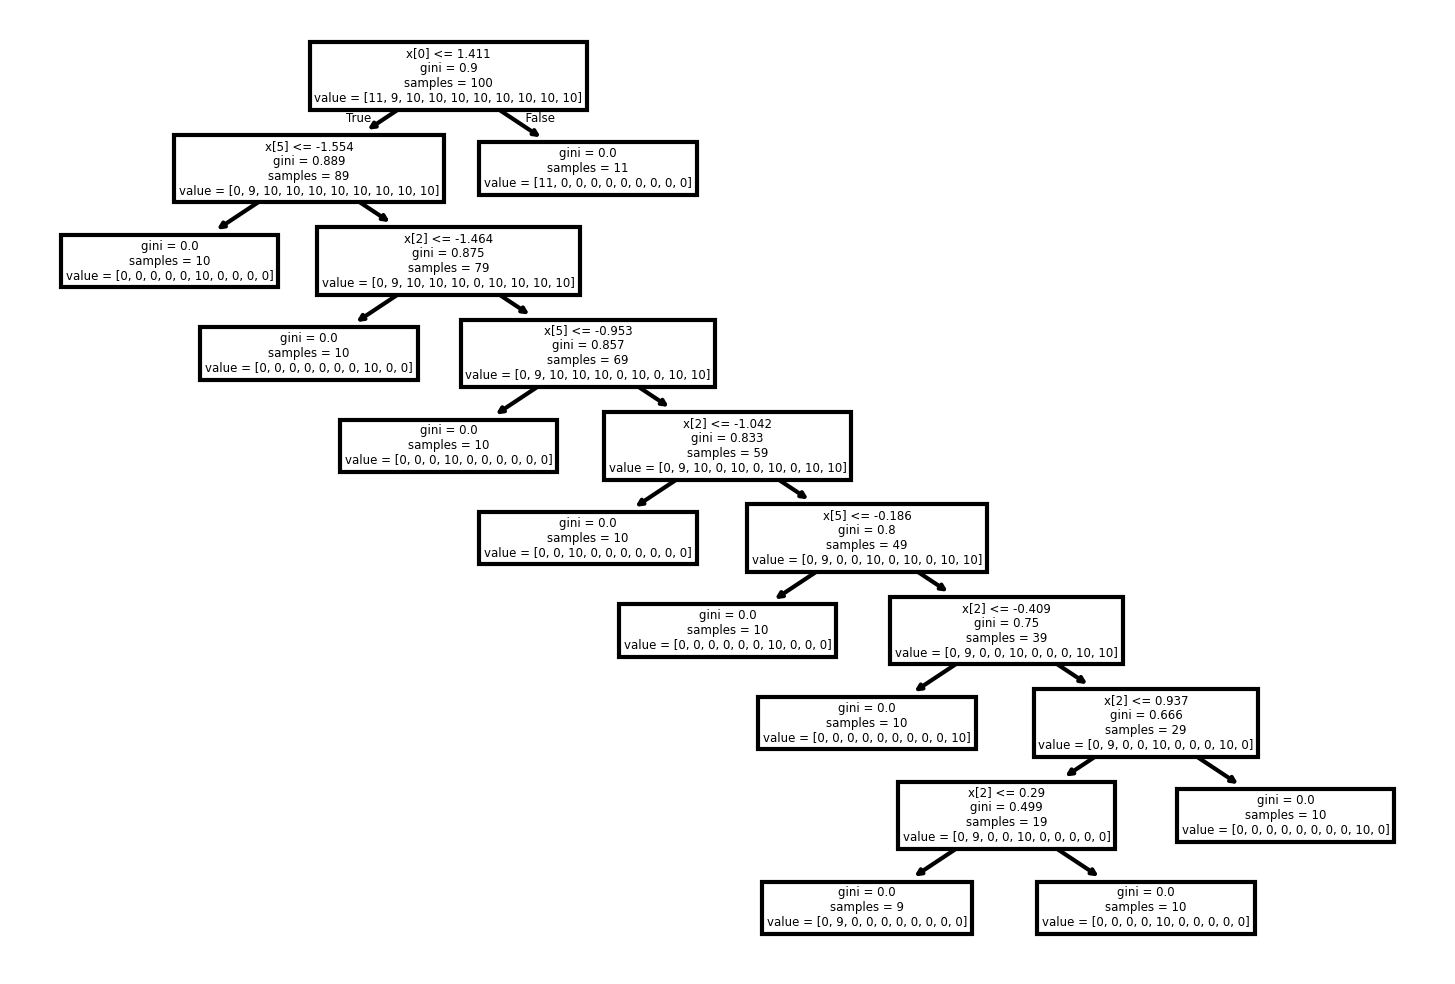

In [7]:
from sklearn import tree
from matplotlib import pyplot as plt
plt.figure(figsize=(6, 4), dpi=300)
tree.plot_tree(method.tree_)
plt.show()

Note that almost all leafnodes have exactly 10 samples, and contain only 1 target value. The leaf nodes are all perfectly homogenous.

Since there are 100 different values, and only 10 target values, the decisiontree can place each observation in a homogenous leafnode and still have more than 5 observations in each leafnode. Since the leafnodes are homogenous, sampling from leafnode does introduce randomness in this case. 

This is an example of [overfitting](https://en.wikipedia.org/wiki/Overfitting). In this case, the consequence of over fitting is information disclosure. 


## The impact of this problem

This situation can happen in realistic settings if the first column is copied:

In [17]:
import pandas as pd

df = pd.DataFrame({'X':X[0], 'y':y})
df['y'] = y
df

,X,y
0,1.3705361439967134,4
1,-0.1115088271429437,0
2,1.0587285298838789,5
3,1.0706105599791862,1
4,-1.1617838439123638,0
...,...,...
95,-0.5336003064391669,2
96,-1.2926253471522626,0
97,-0.16563141031763223,8
98,0.04522270899998256,2


In [18]:
from synthpop.synthesiser import Synthesiser
from synthpop.methods.copy_synth import CopyMethod
synth = Synthesiser(special_syn_method = {"X":CopyMethod()})

synth.fit(df)
syn_df = synth.generate()
syn_df

,X,y
0,1.3705361439967134,4
1,-0.1115088271429437,0
2,1.0587285298838789,5
3,1.0706105599791862,1
4,-1.1617838439123638,0
...,...,...
95,-0.5336003064391669,2
96,-1.2926253471522626,0
97,-0.16563141031763223,8
98,0.04522270899998256,2


In [19]:
syn_df.equals(df)

True

The biggest privacy issue of rare categories is that the relation between variables is reproduced perfectly for those samples. This can lead to undesirable attribute disclosure. 